4### Challenge 3: Random Numbers

**Objective:** Design a Qiskit program with a 3-qubit quantum circuit that uses single-qubit gates to generate a target output probability distribution across specific computational basis states.

---

#### A: Output Target Analysis
Configure the quantum circuit so that measuring the three qubits yields the following probability distribution:
* **$37.5\%$ ($\frac{3}{8}$) probability** of measuring states $|001\rangle$ or $|011\rangle$.
* **$12.5\%$ ($\frac{1}{8}$) probability** of measuring states $|101\rangle$ or $|111\rangle$.

*Note: You do not need to match these percentages exactly down to the decimal point; your goal is to find a set of single-qubit states that produces roughly this distribution across these four specific outcomes.*

#### B: Working Backwards (The Puzzle)
Analyze the target states from Part A to deduce their common properties. Use this structural insight to work backwards and determine which sequence of single-qubit gates ($X, Y, Z, H$, or parameterized rotations) must be applied to each individual qubit to achieve the target superposition.


#### C: Execution and `measure_all`
Ensure your configuration code runs immediately before the script invokes the `measure_all()` method.

* **Method Functionality:** The `measure_all()` method automatically appends a measurement operation to every active qubit in the circuit and dynamically creates a matching classical register to store the resulting output bits.


In [31]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

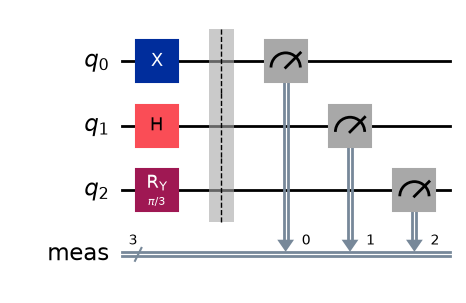

In [32]:
circuit = QuantumCircuit(3)
circuit.x(0)
circuit.h(1)
circuit.ry(pi / 3, 2)

circuit.measure_all()
circuit.draw(output='mpl')

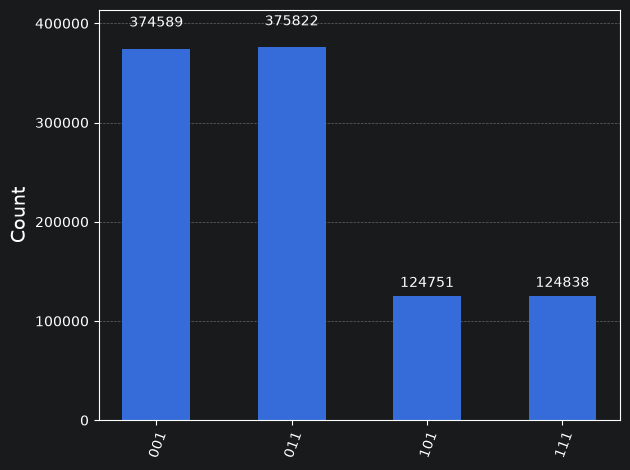

In [33]:
simulator = Aer.get_backend('qasm_simulator') #Quantum Assembly Language
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1000000).result()

plot_histogram(result.get_counts()) # View distribution.